### Simulating 1D lines of electrodes 

- Simulating electrodes where the exponent is -1 for each
- Explore what happens to the output exponent when you average:
    - The time series
    - The PSDs
    - The exponent outputs from the model fit
- Simulate this for both aperiodic and full electrode signals

#### Imports

In [1]:
# Imports required for functionality 
import numpy as np
import matplotlib.pyplot as plt

from dissertation_simulations.params import electrode_sim_params_ap
from dissertation_simulations.params import electrode_sim_params_full
from dissertation_simulations.params import welch_params
from dissertation_simulations.params import spectral_model_params
from dissertation_simulations.params import freq_range

from neurodsp.plts import plot_time_series
from neurodsp.spectral import compute_spectrum_welch

from specparam import SpectralModel
from specparam.plts import plot_spectra

from dissertation_simulations.generate_electrodes import generate_1D_electrodes_ap
from dissertation_simulations.generate_electrodes import generate_1D_electrodes_full

#### Testing the function - 3 electrodes, aperiodic noise only, exponent = -1 for each

Aim:
- Generate 3 electrode signals
- Each electrode signal should have an exponent of -1

In [2]:
exponents = [-1, -1, -1]
signals, params_list, times = generate_1D_electrodes_ap(3, exponents)

##### Plot the time series of the 3 electrode signals

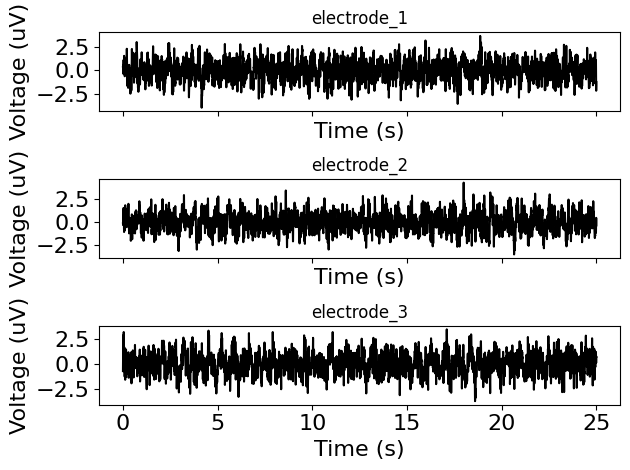

In [3]:
fig, axes = plt.subplots(len(signals), 1, sharex=True)

for ax, (name, signal) in zip(axes, signals.items()):
    plot_time_series(times, signal, ax=ax)
    ax.set_title(name)

plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

#### Averaging the Time Series together

- Compute and plot the average time series for the 3 signals
- Compute and plot the PSD
- Fit the Spectral Model and see what the exponent is

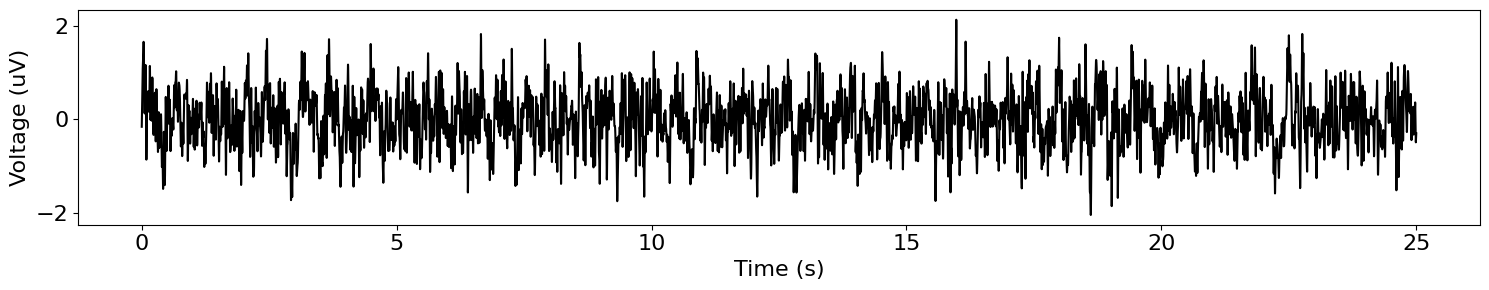

In [4]:
# Convert to array (shape: n_electrodes × n_timepoints)
signal_array = np.array(list(signals.values()))

# Average across electrodes
avg_signal = np.mean(signal_array, axis=0)

# Plot average time series
plot_time_series(times, avg_signal)

##### Plot the PSD

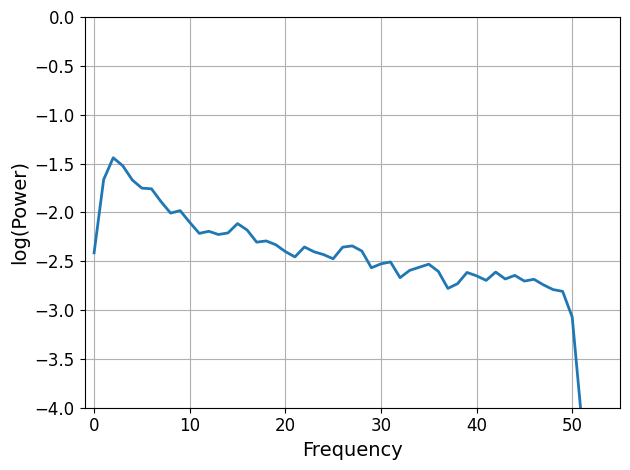

In [5]:
# Compute and plot the PSD, in the frequency domain
params = electrode_sim_params_ap
welch_dict = welch_params(params)

fig, ax = plt.subplots()

freqs, powers = compute_spectrum_welch(avg_signal, fs=params["s_rate"], **welch_dict)
plot_spectra(freqs, powers, log_powers=True, ax=ax)

ax.set_xlim(-1, 55)
ax.set_ylim(-4, 0)

plt.show()

##### Plot Spectral Model

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, exponent)                                        
                                         -1.1189, 0.9973                                          
                                                                                                  
          

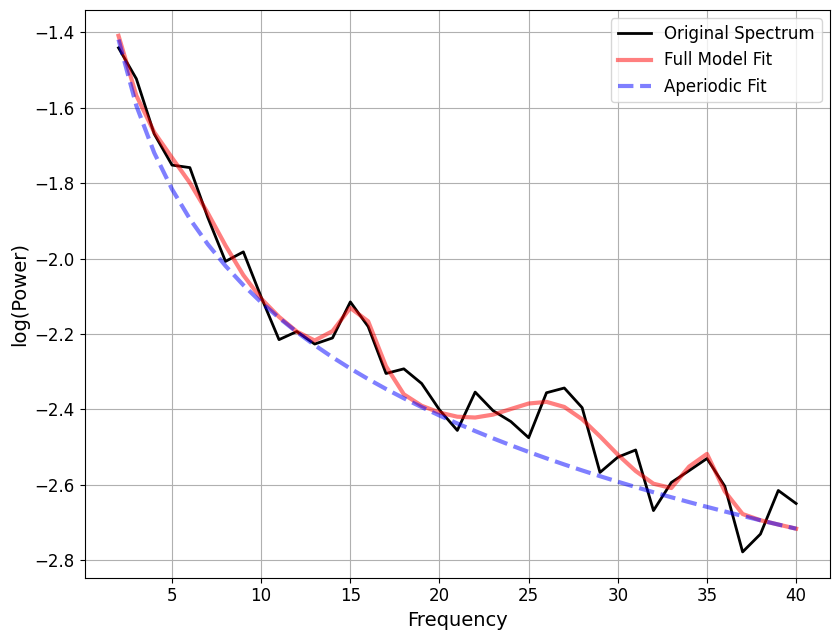

In [6]:
# Plot Spectral Model and look at the exponent output 
fm = SpectralModel(**spectral_model_params)
freq_range = freq_range

fm.report(freqs, powers, freq_range)

Exponent is close to 1 - to be expected

#### Averaging the PSD together

- Compute and plot the time series for the 3 signals
- Compute and plot the average PSD
- Fit the Spectral Model and see what the exponent is

In [7]:
exponents = [-1, -1, -1]
signals, params_list, times = generate_1D_electrodes_ap(3, exponents)

##### Plot the time series of the 3 electrode signals

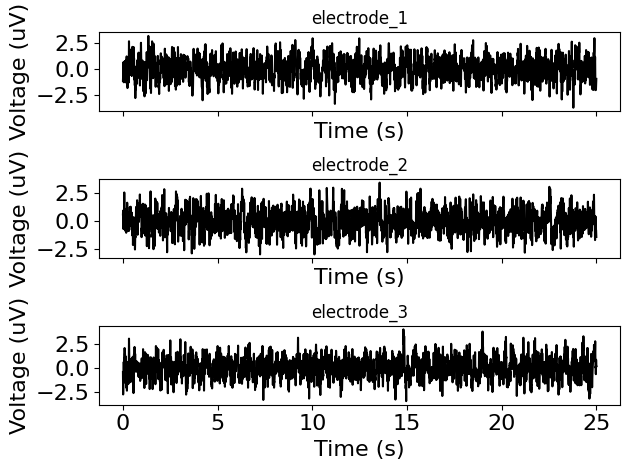

In [8]:
fig, axes = plt.subplots(len(signals), 1, sharex=True)

for ax, (name, signal) in zip(axes, signals.items()):
    plot_time_series(times, signal, ax=ax)
    ax.set_title(name)

plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

##### Plot the PSD for each 

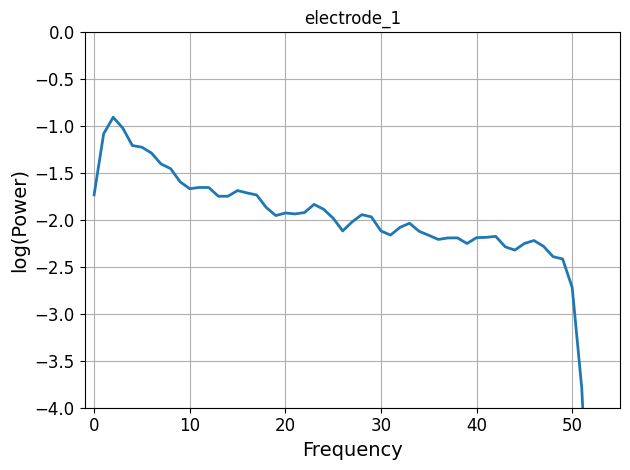

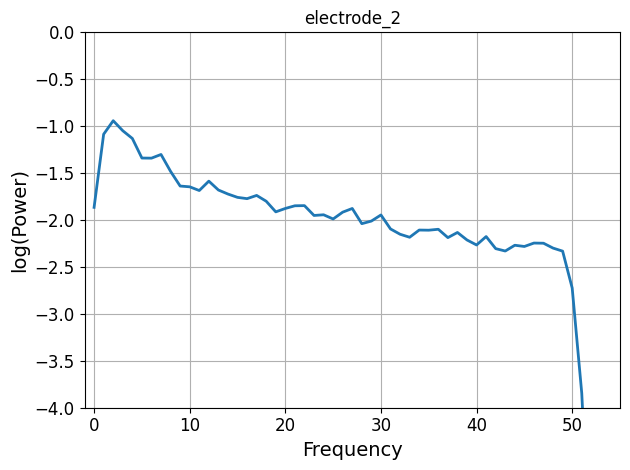

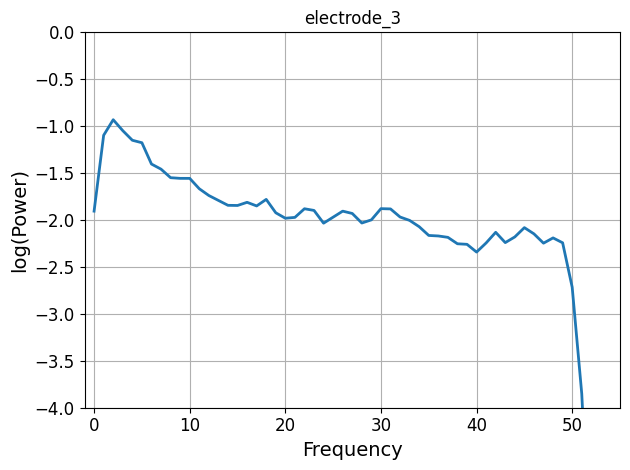

In [9]:
psds = {}

welch_dict = welch_params(params)

for name, signal in signals.items():
    fig, ax = plt.subplots()
    freqs, powers = compute_spectrum_welch(signal, fs=params["s_rate"], **welch_dict)
    
    psds[name] = (freqs, powers)
    plot_spectra(freqs, powers, log_powers=True, ax=ax)

    ax.set_title(name)
    ax.set_xlim(-1, 55)
    ax.set_ylim(-4, 0)

    plt.show()

##### Average the PSDs

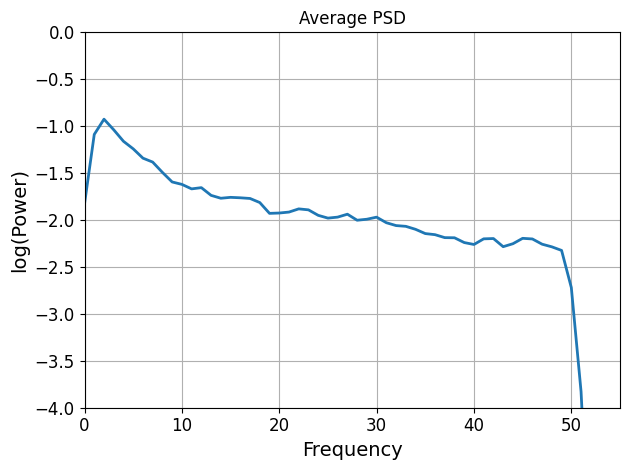

In [10]:
power_array = np.array([powers for freqs, powers in psds.values()])
avg_powers = np.mean(power_array, axis=0)

freqs = list(psds.values())[0][0]

fig, ax = plt.subplots()

plot_spectra(freqs, avg_powers, log_powers=True, ax=ax)

ax.set_title("Average PSD")
ax.set_xlim(0, 55)
ax.set_ylim(-4, 0)

plt.show()

##### Plot Spectral Model

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, exponent)                                        
                                         -0.6141, 1.0049                                          
                                                                                                  
          

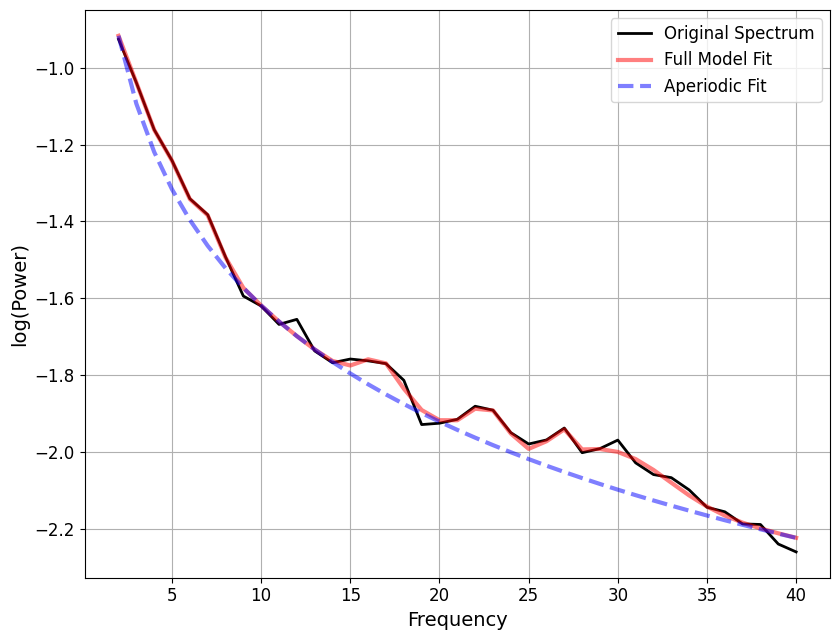

In [11]:
fm = SpectralModel(**spectral_model_params)
freq_range = freq_range

fm.report(freqs, avg_powers, freq_range)

Exponent is close to 1 - to be expected

#### Averaging the Spectral Models together

- Compute and plot the time series for the 3 signals
- Compute and plot the PSDs for the 3 signals
- Fit the Spectral Models for each signal and calculate the average exponent

In [12]:
exponents = [-1, -1, -1]
signals, params_list, times = generate_1D_electrodes_ap(3, exponents)

##### Plot the time series of the 3 electrode signals

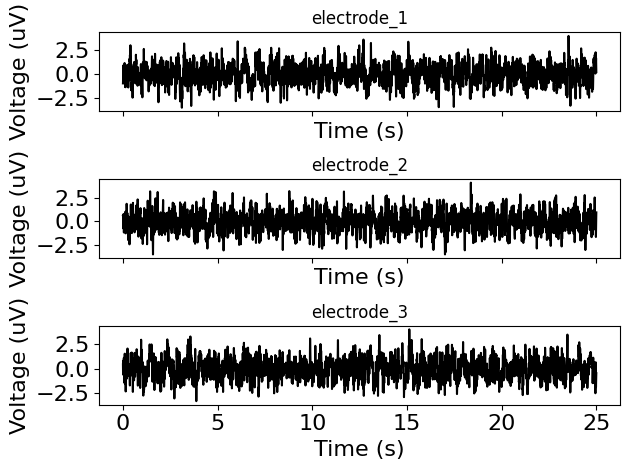

In [13]:
fig, axes = plt.subplots(len(signals), 1, sharex=True)

for ax, (name, signal) in zip(axes, signals.items()):
    plot_time_series(times, signal, ax=ax)
    ax.set_title(name)

plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

##### Plot the PSD for each 

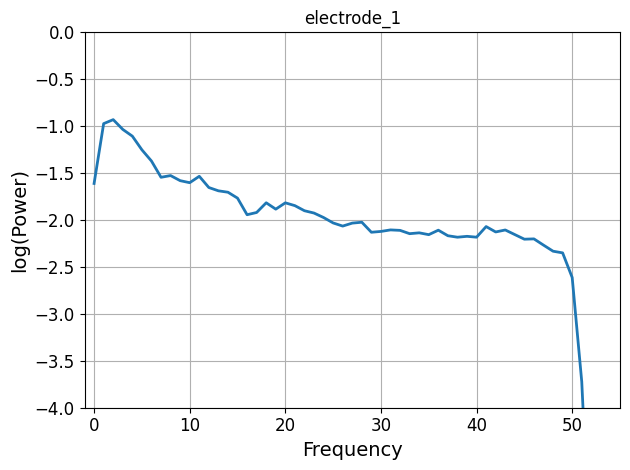

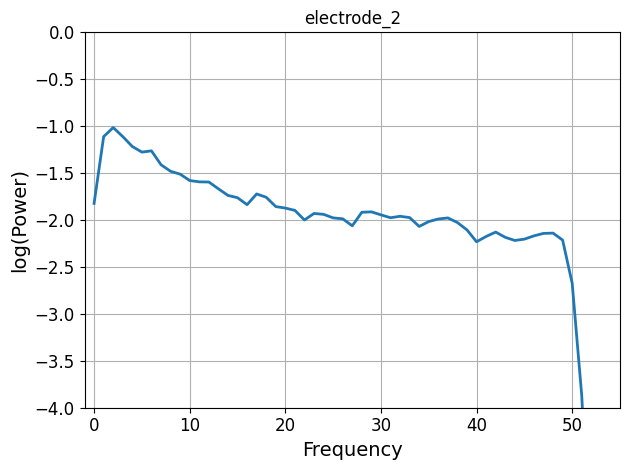

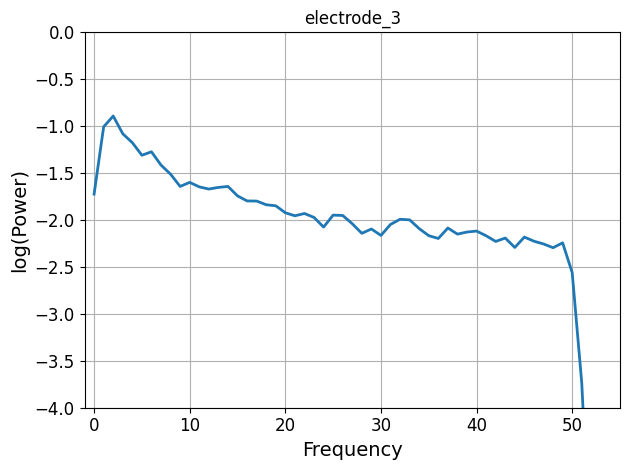

In [14]:
psds = {}

welch_dict = welch_params(params)

for name, signal in signals.items():
    fig, ax = plt.subplots()
    freqs, powers = compute_spectrum_welch(signal, fs=params["s_rate"], **welch_dict)
    
    psds[name] = (freqs, powers)
    plot_spectra(freqs, powers, log_powers=True, ax=ax)

    ax.set_title(name)
    ax.set_xlim(-1, 55)
    ax.set_ylim(-4, 0)

    plt.show()

##### Plot the Spectral Models for each

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, exponent)                                        
                                         -0.6825, 0.9561                                          
                                                                                                  
          

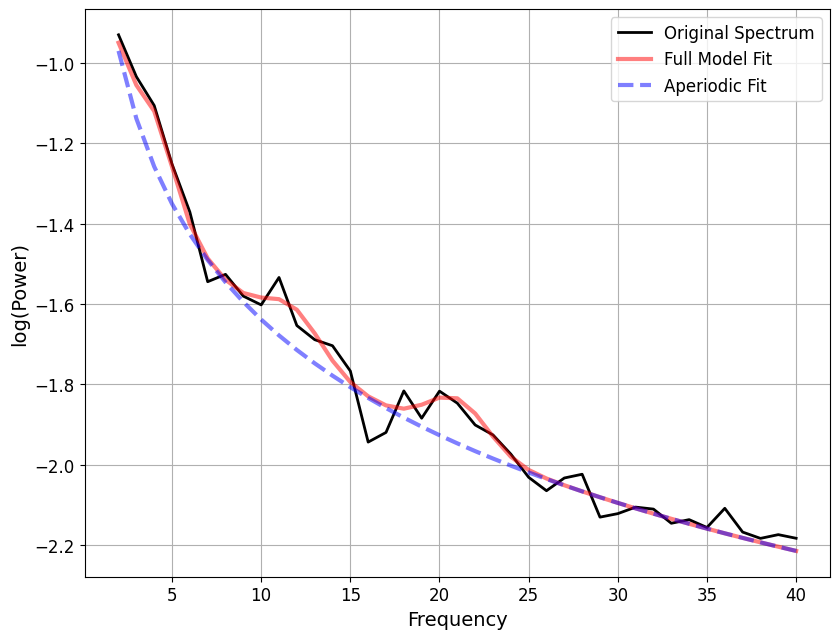

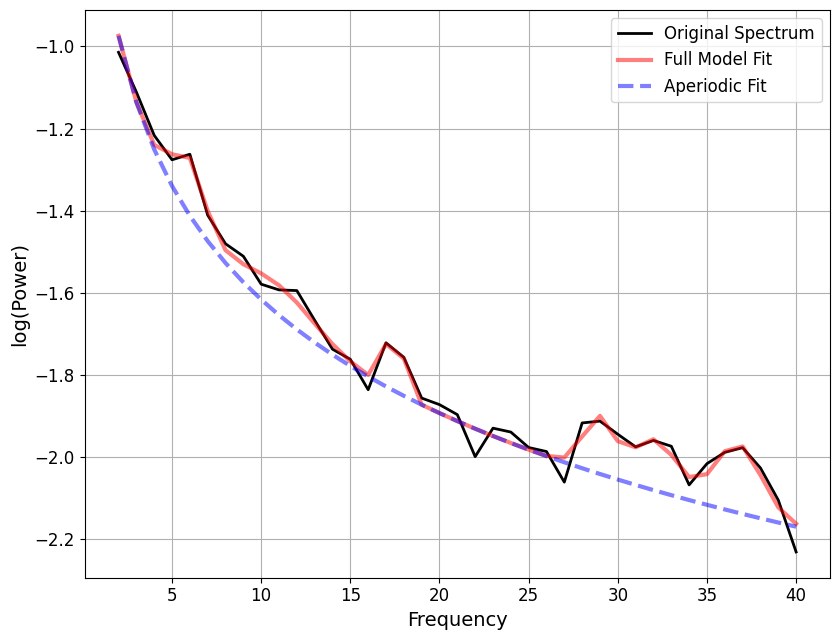

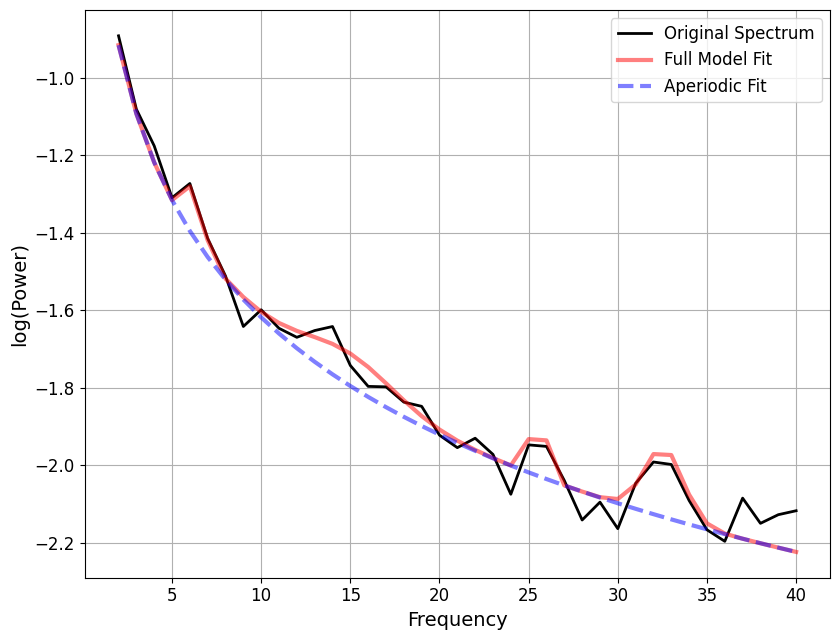

In [15]:
spectral_models = {}

for name, (freqs, powers) in psds.items():

    # Fit model
    fm = SpectralModel(**spectral_model_params)
    freq_range = freq_range
    fm.report(freqs, powers, freq_range)

    spectral_models[name] = fm

##### Calculate average exponent value

In [16]:
exponents = []

for name, fm in spectral_models.items():
    exponent = fm.get_params('aperiodic', 'exponent')
    exponents.append(exponent)
    print(f"{name}: {exponent:.3f}")

avg_exponent = np.mean(exponents)

print(f"Average exponent: {avg_exponent:.3f}")

electrode_1: 0.956
electrode_2: 0.919
electrode_3: 1.006
Average exponent: 0.960


#### Testing the function - 3 electrodes, aperiodic and periodic noise, exponent = -1 for each

Aim:
- Generate 3 electrode signals
- Each electrode signal should have an exponent of -1

In [17]:
exponents = [-1, -1, -1]
signals, params_list, times = generate_1D_electrodes_full(3, exponents)

##### Plot the time series of the 3 electrode signals

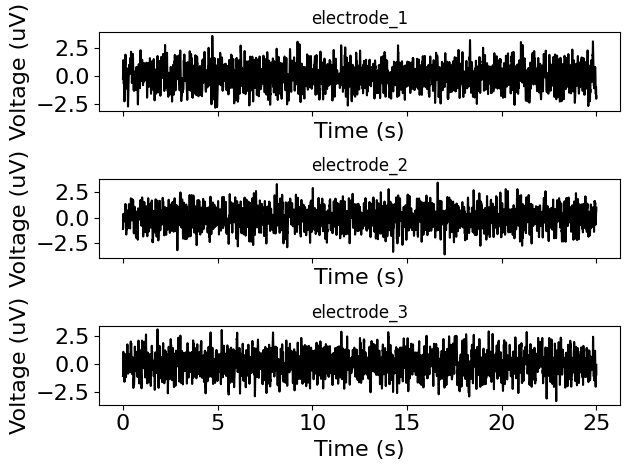

In [18]:
fig, axes = plt.subplots(len(signals), 1, sharex=True)

for ax, (name, signal) in zip(axes, signals.items()):
    plot_time_series(times, signal, ax=ax)
    ax.set_title(name)

plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

#### Averaging the Time Series together

- Compute and plot the average time series for the 3 signals
- Compute and plot the PSD
- Fit the Spectral Model and see what the exponent is

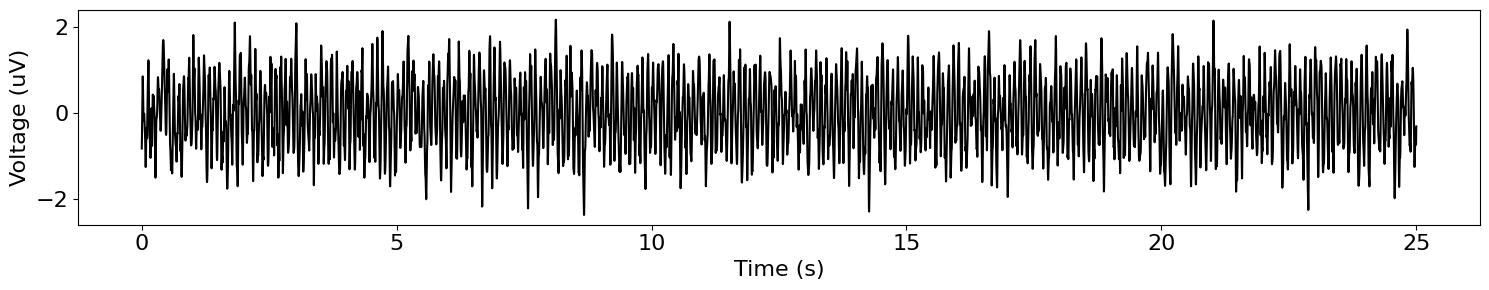

In [19]:
# Convert to array (shape: n_electrodes × n_timepoints)
signal_array = np.array(list(signals.values()))

# Average across electrodes
avg_signal = np.mean(signal_array, axis=0)

# Plot average time series
plot_time_series(times, avg_signal)

##### Plot the PSD

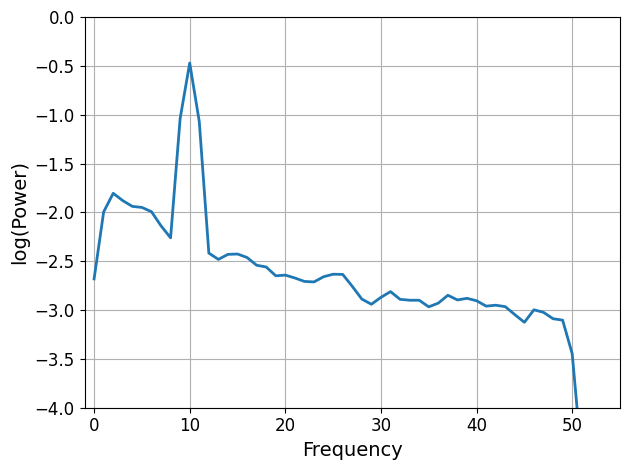

In [20]:
# Compute and plot the PSD, in the frequency domain
params = electrode_sim_params_full
welch_dict = welch_params(params)

fig, ax = plt.subplots()

freqs, powers = compute_spectrum_welch(avg_signal, fs=params["s_rate"], **welch_dict)
plot_spectra(freqs, powers, log_powers=True, ax=ax)

ax.set_xlim(-1, 55)
ax.set_ylim(-4, 0)

plt.show()

##### Plot the Spectral Model

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, exponent)                                        
                                         -1.3754, 0.9731                                          
                                                                                                  
          

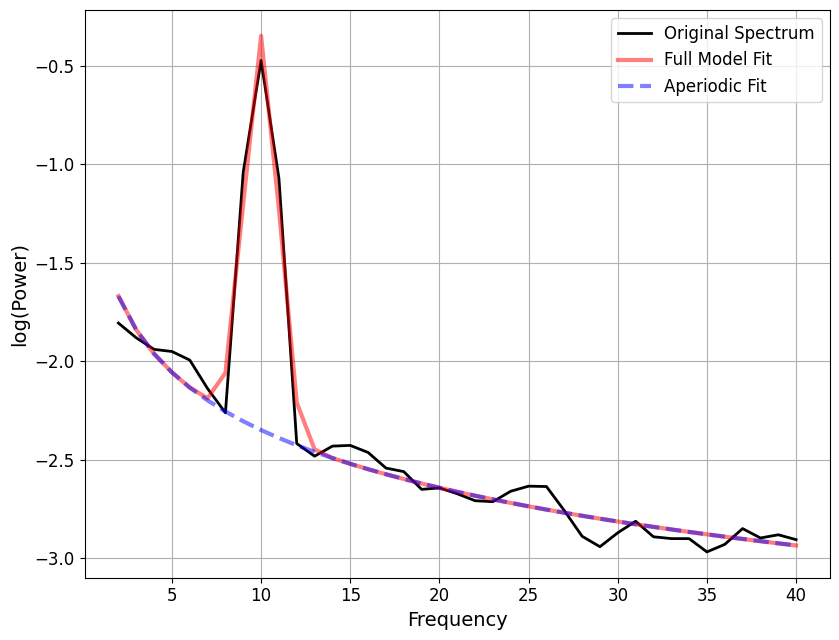

In [21]:
# Plot Spectral Model and look at the exponent output 
fm = SpectralModel(**spectral_model_params)
freq_range = freq_range

fm.report(freqs, powers, freq_range)

Exponent is close to 1 - to be expected

#### Averaging the PSD together

- Compute and plot the time series for the 3 signals
- Compute and plot the average PSD
- Fit the Spectral Model and see what the exponent is

In [22]:
exponents = [-1, -1, -1, -1]
signals, params_list, times = generate_1D_electrodes_full(4, exponents)

##### Plot the time series for each electrode

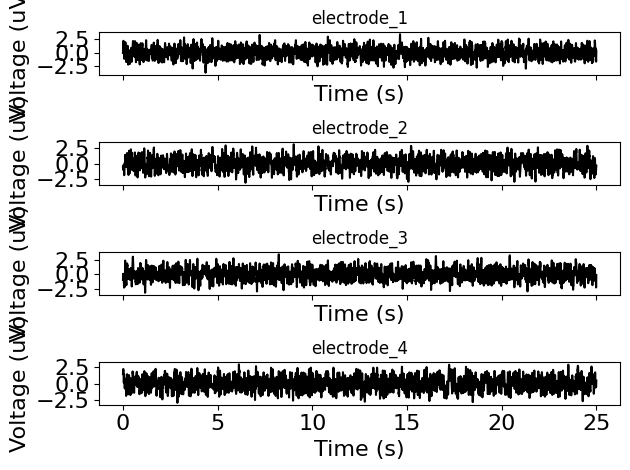

In [23]:
fig, axes = plt.subplots(len(signals), 1, sharex=True)

for ax, (name, signal) in zip(axes, signals.items()):
    plot_time_series(times, signal, ax=ax)
    ax.set_title(name)

plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

##### Plot indidivual PSDs

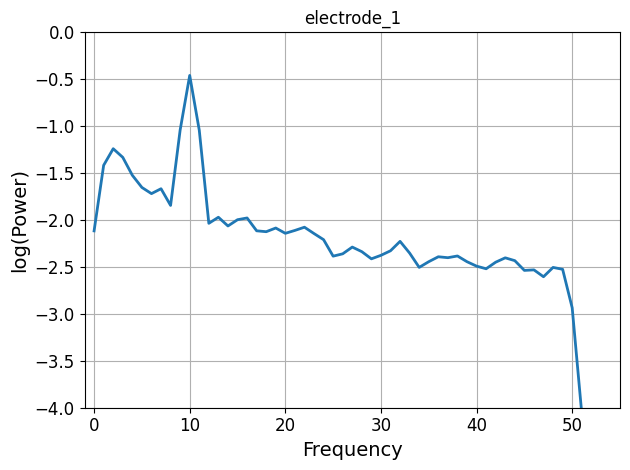

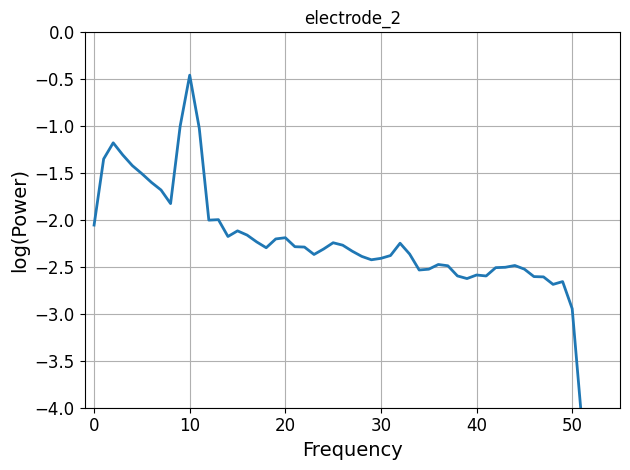

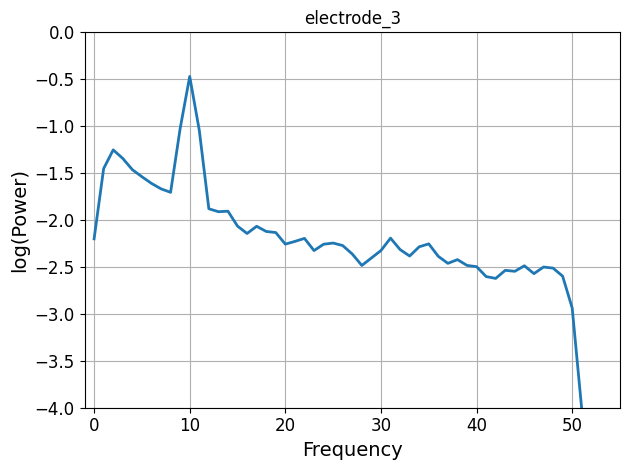

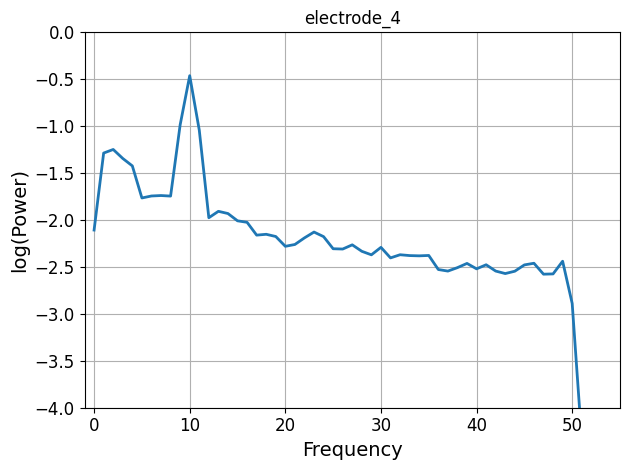

In [24]:
psds = {}

params = electrode_sim_params_full
welch_dict = welch_params(params)

for name, signal in signals.items():
    fig, ax = plt.subplots()
    freqs, powers = compute_spectrum_welch(signal, fs=params["s_rate"], **welch_dict)
    
    psds[name] = (freqs, powers)
    plot_spectra(freqs, powers, log_powers=True, ax=ax)

    ax.set_title(name)
    ax.set_xlim(-1, 55)
    ax.set_ylim(-4, 0)

    plt.show()

##### Plot average PSD

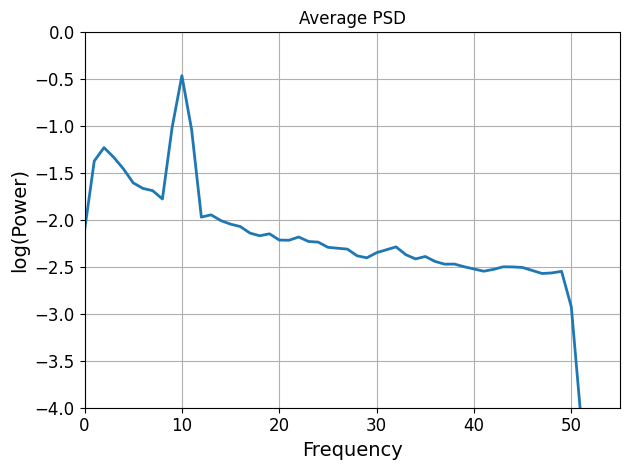

In [25]:
power_array = np.array([powers for freqs, powers in psds.values()])
avg_powers = np.mean(power_array, axis=0)

freqs = list(psds.values())[0][0]

fig, ax = plt.subplots()

plot_spectra(freqs, avg_powers, log_powers=True, ax=ax)

ax.set_title("Average PSD")
ax.set_xlim(0, 55)
ax.set_ylim(-4, 0)

plt.show()

##### Plot the Spectral Model

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, exponent)                                        
                                         -0.8942, 0.9902                                          
                                                                                                  
          

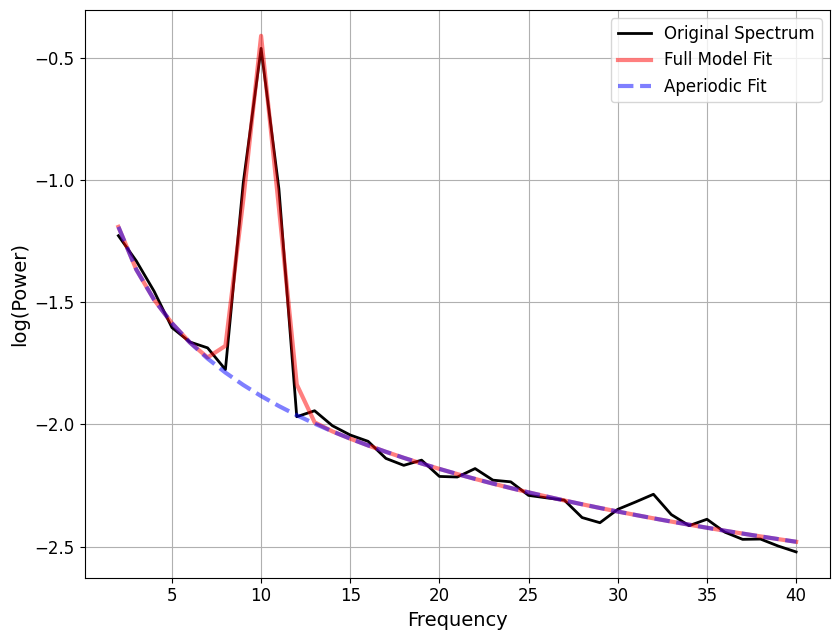

In [26]:
# Plot Spectral Model and look at the exponent output 
fm = SpectralModel(**spectral_model_params)
freq_range = freq_range

fm.report(freqs, avg_powers, freq_range)

Exponet close to 1 - to be expected

#### Averaging the Spectral Models together

- Compute and plot the time series for the 3 signals
- Compute and plot the PSDs for the 3 signals
- Fit the Spectral Models for each signal and calculate the average exponent

In [27]:
exponents = [-1, -1, -1, -1]
signals, params_list, times = generate_1D_electrodes_full(4, exponents)

##### Plot the Time Series for each electrode

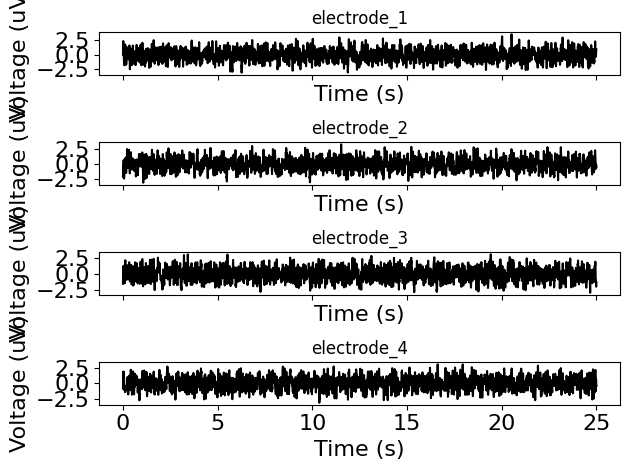

In [28]:
fig, axes = plt.subplots(len(signals), 1, sharex=True)

for ax, (name, signal) in zip(axes, signals.items()):
    plot_time_series(times, signal, ax=ax)
    ax.set_title(name)

plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

##### Plot individual PSDs

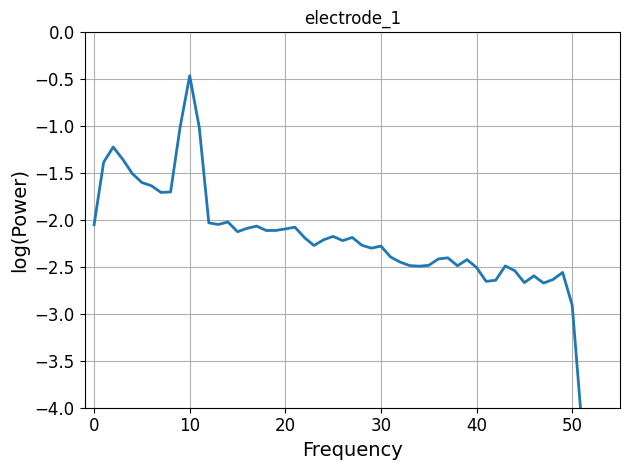

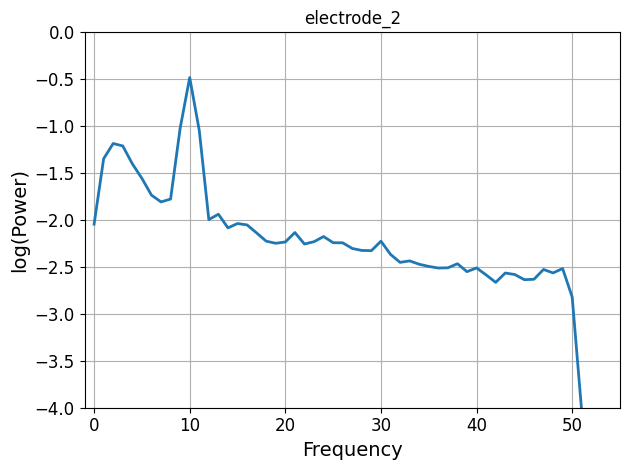

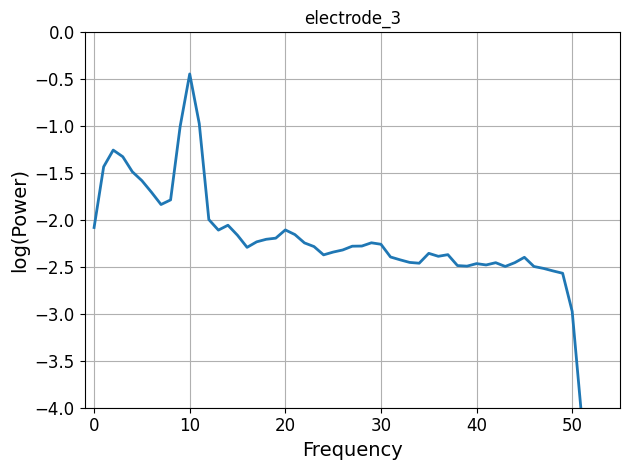

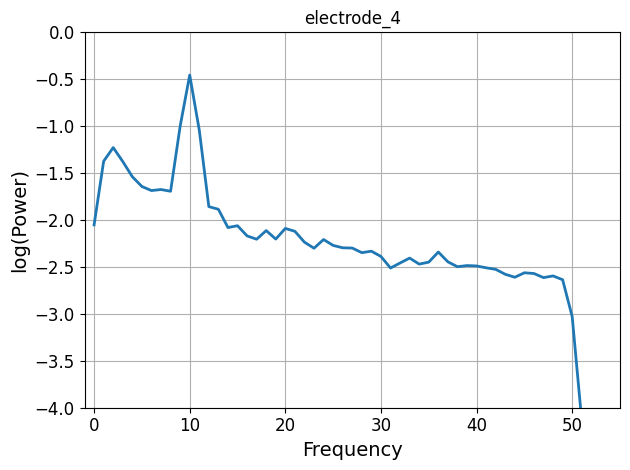

In [29]:
psds = {}

params = electrode_sim_params_full
welch_dict = welch_params(params)

for name, signal in signals.items():
    fig, ax = plt.subplots()
    freqs, powers = compute_spectrum_welch(signal, fs=params["s_rate"], **welch_dict)
    
    psds[name] = (freqs, powers)
    plot_spectra(freqs, powers, log_powers=True, ax=ax)

    ax.set_title(name)
    ax.set_xlim(-1, 55)
    ax.set_ylim(-4, 0)

    plt.show()

##### Plot individual Spectral Models

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, exponent)                                        
                                         -0.9153, 0.9654                                          
                                                                                                  
          

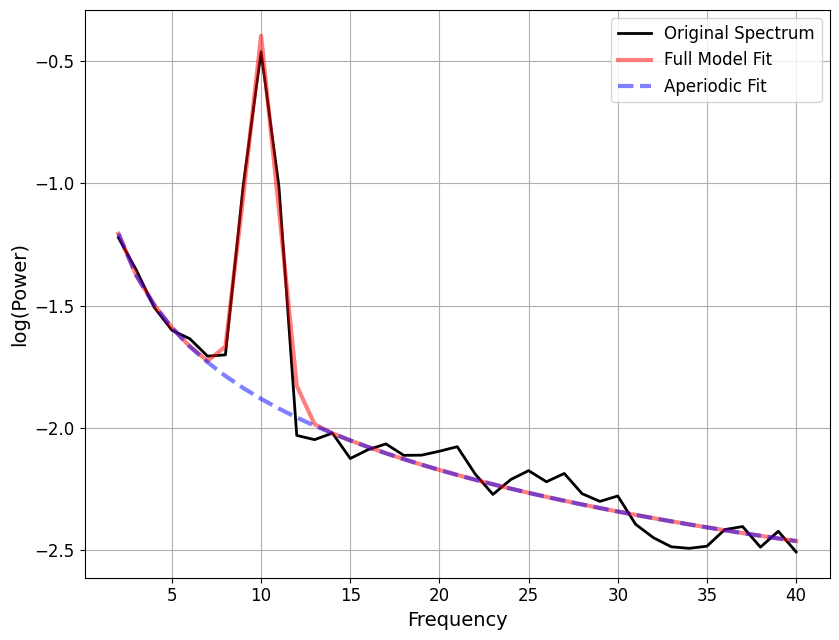

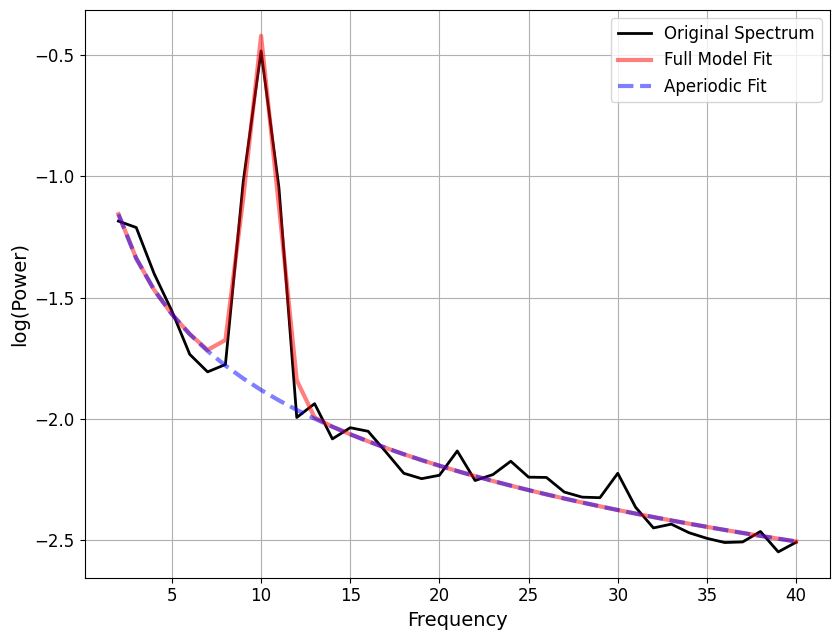

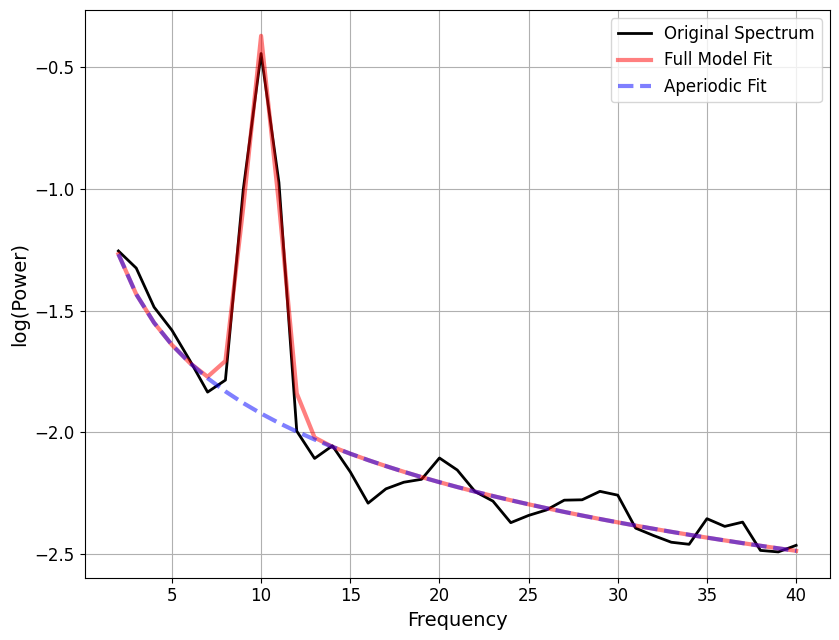

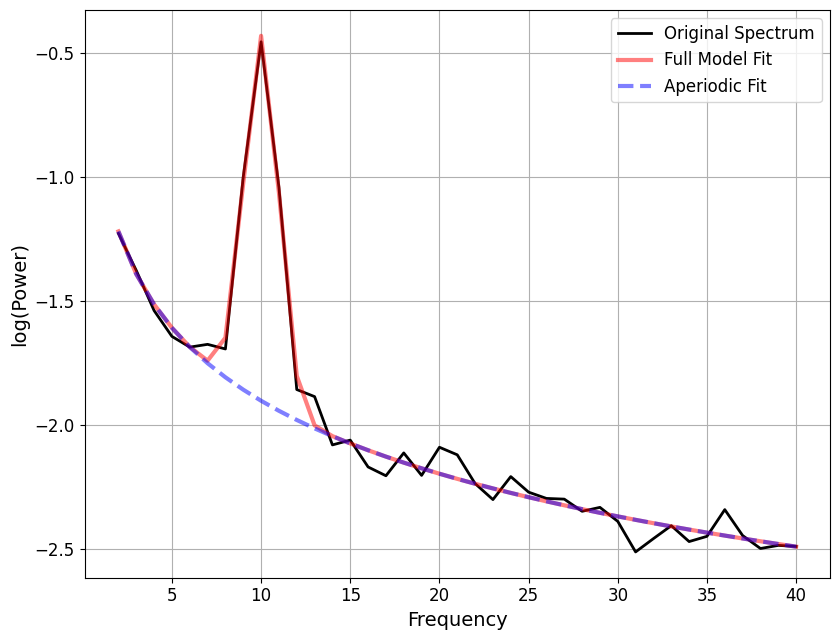

In [30]:
spectral_models = {}

for name, (freqs, powers) in psds.items():

    # Fit model
    fm = SpectralModel(**spectral_model_params)
    freq_range = freq_range
    fm.report(freqs, powers, freq_range)

    spectral_models[name] = fm

##### Average Spectral Model exponent

In [31]:
exponents = []

for name, fm in spectral_models.items():
    exponent = fm.get_params('aperiodic', 'exponent')
    exponents.append(exponent)
    print(f"{name}: {exponent:.3f}")

avg_exponent = np.mean(exponents)

print(f"Average exponent: {avg_exponent:.3f}")

electrode_1: 0.965
electrode_2: 1.039
electrode_3: 0.937
electrode_4: 0.977
Average exponent: 0.980
